# ゼロから作る Deep Learning ❸ 輪読会
## 第1ステージ「微分を自動で求める」 ― ステップ 6 〜 10

**はじめに**：
* 前回 (ステップ 1〜5) では、データを入れる箱としての `Variable` と、箱を受け取り箱を返す `Function` を実装し、関数を連結して合成関数を作った。
* さらに、数値微分を実装し、その問題点 (誤差と計算コスト) を解決する手法としてバックプロパゲーションの理論を確認した。
* 今回は、その理論をコードに落とし込む。前回最後に整理した 3 点 ―「変数は通常の値と微分値を持つ」「関数は forward と backward を持つ」「逆伝播には順伝播の値が必要」― が、そのまま実装の設計図になる。

**このステージの目標**：
* 前回掲げた次のコードを、今回ついに動くようにする。`y.backward()` を実行するだけで、微分 `dy/dx` が自動的に計算される。
* あわせて、実装が正しいことをいつでも確認できるように、テストの仕組みも整える。

```python
x = Variable(np.array(0.5))
y = square(exp(square(x)))  # y = (exp(x^2))^2
y.backward()
print(x.grad)               # dy/dx を自動で求める
```

> **Table of contents**
> 1. ステップ 6：手作業によるバックプロパゲーション
> 2. ステップ 7：バックプロパゲーションの自動化
> 3. ステップ 8：再帰からループへ
> 4. ステップ 9：関数をより便利に
> 5. ステップ 10：テストを行う

## ライブラリの読み込み

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

np.random.seed(0)
print("NumPy version:", np.__version__)


# --- matplotlib の日本語フォント設定 ---------------------------------------
# インストール済みフォント → Windows のフォント (WSL) の順に日本語フォントを探して設定する
def setup_japanese_font():
    preferred = ["Noto Sans CJK JP", "IPAexGothic", "IPAGothic", "TakaoGothic",
                 "BIZ UDGothic", "Yu Gothic", "Meiryo", "MS Gothic", "Hiragino Sans"]
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in preferred:
        if name in installed:
            plt.rcParams["font.family"] = name
            plt.rcParams["axes.unicode_minus"] = False  # マイナス記号の文字化け対策
            return name
    # WSL では Windows 側のフォントを直接登録して使う
    for path in ["/mnt/c/Windows/Fonts/BIZ-UDGothicR.ttc",
                 "/mnt/c/Windows/Fonts/meiryo.ttc",
                 "/mnt/c/Windows/Fonts/msgothic.ttc",
                 "/mnt/c/Windows/Fonts/YuGothM.ttc"]:
        if os.path.exists(path):
            font_manager.fontManager.addfont(path)
            name = font_manager.FontProperties(fname=path).get_name()
            plt.rcParams["font.family"] = name
            plt.rcParams["axes.unicode_minus"] = False
            return name
    return None


jp_font = setup_japanese_font()
print("図の日本語フォント:", jp_font if jp_font else "見つからず (図中の日本語は文字化けします)")

# 図を高解像度 (2 倍) で描画して、小さな文字も鮮明に表示する
%config InlineBackend.figure_format = "retina"

NumPy version: 1.26.4
図の日本語フォント: BIZ UDGothic


---
# ステップ 6：手作業によるバックプロパゲーション

前回のステップ 5 で、バックプロパゲーション (誤差逆伝播法) の理論を確認した。このステップでは、それをまず手作業で実装する。自動化は次のステップで行うが、「何を自動化したいのか」を体で理解するために、一度自分の手で逆伝播を書いてみる。

## 6.1 `Variable` クラスの追加実装

ステップ 5 の対応表で見たとおり、逆伝播では変数ごとに「通常の値」と「微分の値」がペアで登場する (順伝播の $x, a, b, y$ に対して $\frac{dy}{dx}, \frac{dy}{da}, \frac{dy}{db}, \frac{dy}{dy}$)。そこで `Variable` に、通常の値 `data` と対になる微分値 `grad` を持たせる。

- `grad` は `None` で初期化し、逆伝播で実際に微分が計算されたときに値を設定する
- 機械学習では、ベクトルや行列 (多変数) に関する微分をまとめて勾配 (gradient) と呼ぶ。変数名 `grad` はその略

| 順伝播の変数 (`data`) | 対応する微分 (`grad`) |
|---|---|
| $x$ | $dy/dx$ |
| $a$ | $dy/da$ |
| $b$ | $dy/db$ |
| $y$ | $dy/dy \, (= 1)$ |

In [2]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None  # ★ 追加：data に対応する微分値。逆伝播で計算されるまでは None

## 6.2 `Function` クラスの追加実装

`Function` には 2 つの機能を追加する。

1. **`backward` メソッド**：微分を計算する逆伝播。順伝播の `forward` と対をなす。
2. **入力 `Variable` の保持**：`__call__` の中で、入力を `self.input` として覚えておく。

2 が必要になる理由は、ステップ 5 の最後に確認した「逆伝播には順伝播時の値が必要」だから。たとえば $y = x^2$ の微分 $2x$ を計算するには、順伝播で入力された $x$ の値が要る。そこで関数が呼ばれた時点で入力を記憶しておき、`backward` のときに取り出して使う。

In [3]:
class Function:
    def __call__(self, input):
        x = input.data
        y = self.forward(x)
        output = Variable(y)
        self.input = input  # ★ 追加：逆伝播で使うため、入力の Variable を覚えておく
        return output

    def forward(self, x):
        raise NotImplementedError()

    def backward(self, gy):  # ★ 追加：逆伝播。gy は出力側から流れてきた微分
        raise NotImplementedError()

## 6.3 `Square` と `Exp` の逆伝播

具体的な関数に `backward` を実装する。引数 `gy` は「出力側から流れてきた微分」であり、これに各関数の局所的な導関数を掛けて入力側へ流す、というのがチェインルールだった。

- $y = x^2$ の導関数は $\dfrac{dy}{dx} = 2x$ なので、流す値は `gx = 2 * x * gy`
- $y = e^x$ の導関数は $\dfrac{dy}{dx} = e^x$ なので、流す値は `gx = np.exp(x) * gy`

どちらの `backward` も、順伝播のときに覚えておいた入力 `self.input.data` を使っている点に注目。

In [4]:
class Square(Function):
    def forward(self, x):
        y = x ** 2
        return y

    def backward(self, gy):
        x = self.input.data  # 順伝播のときの入力を取り出す
        gx = 2 * x * gy      # 導関数 2x に、上流からの微分 gy を掛ける
        return gx


class Exp(Function):
    def forward(self, x):
        y = np.exp(x)
        return y

    def backward(self, gy):
        x = self.input.data
        gx = np.exp(x) * gy  # 導関数 e^x に gy を掛ける
        return gx

## 6.4 バックプロパゲーションの実装

ステップ 3 と同じ合成関数 $y = (e^{x^2})^2$ で試す。順伝播は前回どおり。

$$ x \to \boxed{A=\text{Square}} \to a \to \boxed{B=\text{Exp}} \to b \to \boxed{C=\text{Square}} \to y $$

逆伝播は、この逆順に `backward` を手作業で呼んでいく。出発点は $\dfrac{dy}{dy} = 1$ なので、最初に `y.grad = np.array(1.0)` をセットし、あとは $C \to B \to A$ の順で微分を伝える。

In [5]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)

# 逆伝播：順伝播と逆の順番で backward を呼ぶ
y.grad = np.array(1.0)       # 出発点 dy/dy = 1
b.grad = C.backward(y.grad)  # dy/db
a.grad = B.backward(b.grad)  # dy/da
x.grad = A.backward(a.grad)  # dy/dx ← 求めたかった微分
print("x.grad =", x.grad)

x.grad = 3.297442541400256


いま計算した値を図で確かめる。上段が順伝播 (`data`)、下段が逆伝播 (`grad`) で、点線で結ばれた上下の変数が「値と微分のペア」である。ステップ 5 で理論として見た「順伝播と逆伝播の対応関係」が、そのまま数値として並ぶ。

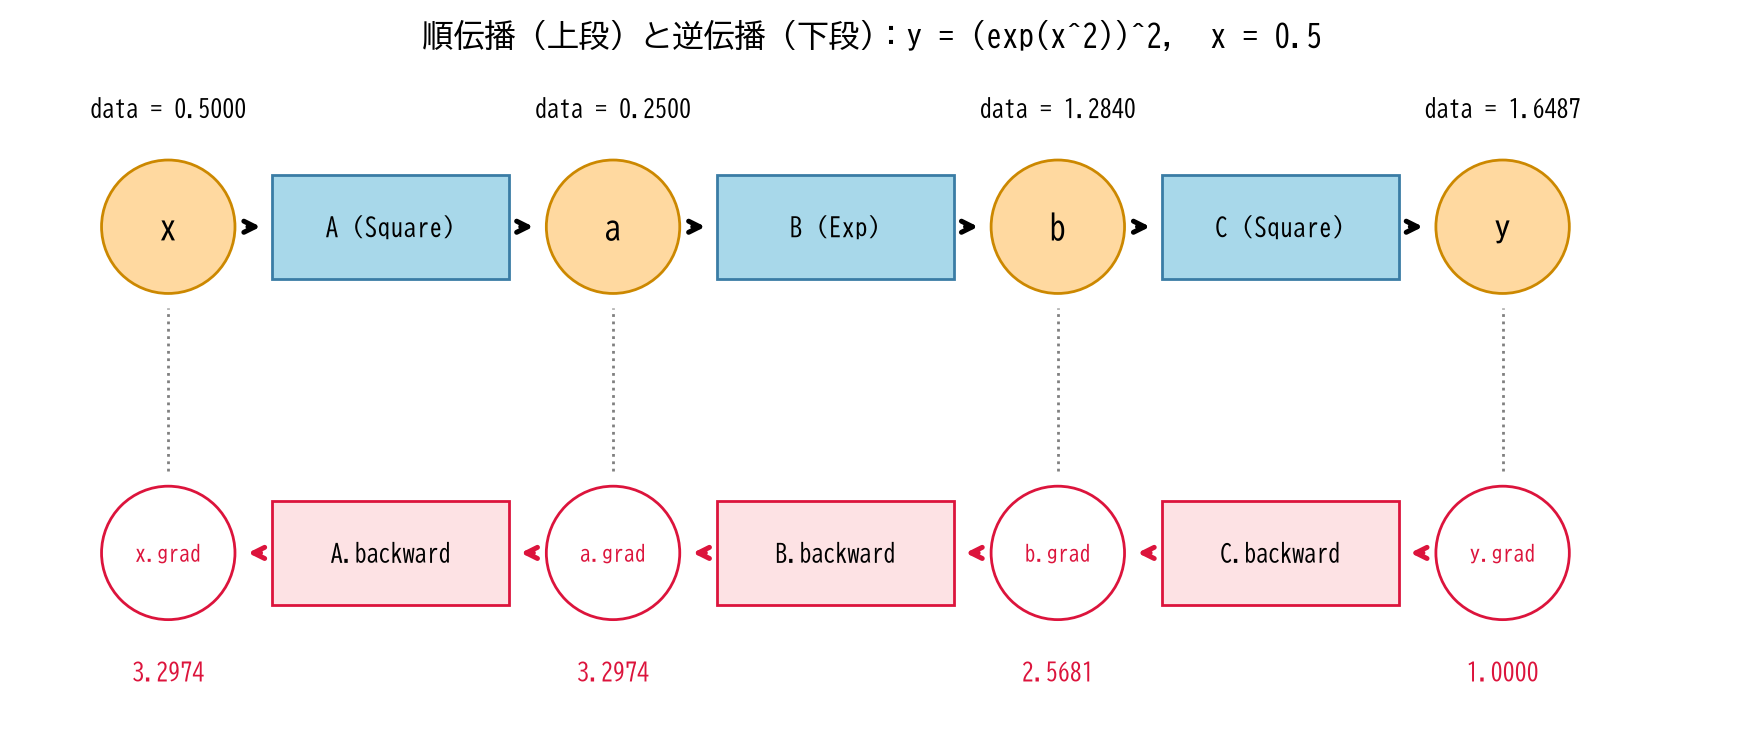

In [6]:
# 上段が順伝播 (data)、下段が逆伝播 (grad)。値は直前のセルで計算したものをそのまま使う
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.axis('off')
ax.set_aspect('equal')

top, bot = 2.8, 0.6
var_xs = [0, 3, 6, 9]
fun_xs = [1.5, 4.5, 7.5]
var_names = ["x", "a", "b", "y"]
data_vals = [x.data, a.data, b.data, y.data]
grad_vals = [x.grad, a.grad, b.grad, y.grad]

# 上下の変数ペア (data と grad の対応) を点線で結ぶ
for xi in var_xs:
    ax.plot([xi, xi], [bot + 0.55, top - 0.55], ls=":", color="gray", lw=1, zorder=1)

# 上段：順伝播 (黒、左 → 右)
for xi, name, v in zip(var_xs, var_names, data_vals):
    ax.add_patch(plt.Circle((xi, top), 0.45, color="#ffd9a0", ec="#cc8800", zorder=2))
    ax.text(xi, top, name, ha="center", va="center", fontsize=12, zorder=3)
    ax.text(xi, top + 0.8, f"data = {float(v):.4f}", ha="center", va="center", fontsize=8.5)
for xi, name in zip(fun_xs, ["A (Square)", "B (Exp)", "C (Square)"]):
    ax.add_patch(plt.Rectangle((xi - 0.8, top - 0.35), 1.6, 0.7, color="#a8d8ea", ec="#3a7ca5", zorder=2))
    ax.text(xi, top, name, ha="center", va="center", fontsize=9, zorder=3)
for x1, x2 in [(0.5, 0.66), (2.34, 2.5), (3.5, 3.66), (5.34, 5.5), (6.5, 6.66), (8.34, 8.5)]:
    ax.annotate("", xy=(x2, top), xytext=(x1, top),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.8))

# 下段：逆伝播 (赤、右 → 左)
for xi, name, v in zip(var_xs, var_names, grad_vals):
    ax.add_patch(plt.Circle((xi, bot), 0.45, color="white", ec="crimson", zorder=2))
    ax.text(xi, bot, f"{name}.grad", ha="center", va="center", fontsize=7.5, color="crimson", zorder=3)
    ax.text(xi, bot - 0.8, f"{float(v):.4f}", ha="center", va="center", fontsize=8.5, color="crimson")
for xi, name in zip(fun_xs, ["A.backward", "B.backward", "C.backward"]):
    ax.add_patch(plt.Rectangle((xi - 0.8, bot - 0.35), 1.6, 0.7, color="#fde2e4", ec="crimson", zorder=2))
    ax.text(xi, bot, name, ha="center", va="center", fontsize=8.5, zorder=3)
for x1, x2 in [(0.5, 0.66), (2.34, 2.5), (3.5, 3.66), (5.34, 5.5), (6.5, 6.66), (8.34, 8.5)]:
    ax.annotate("", xy=(x1, bot), xytext=(x2, bot),
                arrowprops=dict(arrowstyle="->", color="crimson", lw=1.8))

ax.set_xlim(-1, 10.5)
ax.set_ylim(-0.5, 3.9)
ax.set_title("順伝播 (上段) と逆伝播 (下段)：y = (exp(x^2))^2,  x = 0.5", fontsize=11)
plt.show()

結果は `3.2974...` となり、ステップ 4 で数値微分により求めた値とほぼ一致する。前回実装した `numerical_diff` を再掲し、その場で突き合わせて確認しておく (これが前回予告した「勾配確認」の考え方である)。

In [7]:
def numerical_diff(f, x, eps=1e-4):
    # ステップ 4 (前回) で実装した、中心差分による数値微分
    x0 = Variable(x.data - eps)
    x1 = Variable(x.data + eps)
    y0 = f(x0)
    y1 = f(x1)
    return (y1.data - y0.data) / (2 * eps)


def f(x):
    A, B, C = Square(), Exp(), Square()
    return C(B(A(x)))  # y = (exp(x^2))^2


num_grad = numerical_diff(f, Variable(np.array(0.5)))
print("バックプロパゲーション :", x.grad)
print("数値微分               :", num_grad)
print("差の絶対値             :", abs(x.grad - num_grad))

バックプロパゲーション : 3.297442541400256
数値微分               : 3.2974426293330694
差の絶対値             : 8.793281347507786e-08


> **ステップ 6 のまとめ**
> - `Variable` は `data` (通常の値) に加えて `grad` (微分値) を持つようになった。
> - `Function` は `forward` (順伝播) と `backward` (逆伝播) の 2 つの計算を持ち、逆伝播に備えて入力を `self.input` に記憶する。
> - 出力側から順に `backward` を呼ぶと微分が求まり、結果は数値微分と一致した。
> - ただし、逆伝播の順番 ($C \to B \to A$) を人間が手で書くのは面倒で間違えやすい。次のステップで自動化する。

---
# ステップ 7：バックプロパゲーションの自動化

ステップ 6 の逆伝播は動くものの、順伝播のコードを書き換えるたびに、逆順の `backward` 呼び出しも手で書き直さなければならない。計算が複雑になれば、この作業は退屈でミスの温床になる。そこで、順伝播を一度実行すれば、どんな計算に対しても逆伝播が自動で行われる仕組みを作る。

## 7.1 変数と関数の「つながり」を記録する

自動化の鍵は、計算グラフのつながりをデータとして記録しておくことである。関数と変数の関係を整理すると、次のようになる。

- 関数から見ると：入力の変数 (`input`) と出力の変数 (`output`) が存在する
- 変数から見ると：自分を生み出した関数、いわば生みの親 (creator) が存在する。ユーザーが直接作った変数 (グラフの端) には生みの親がいない (`None`)

このつながりを、計算が実行されるまさにその瞬間に記録する。具体的には `Function.__call__` の中で、出力変数に「私があなたの生みの親だ」と知らせ (`output.set_creator(self)`)、あわせて関数自身も出力を `self.output` として覚えておく。

> このように「計算の実行と同時につながり (計算グラフ) が作られる」方式を **Define-by-Run** (動的計算グラフ) と呼ぶ。PyTorch や Chainer が採用している方式であり、DeZero もこの仲間である。

In [8]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None  # ★ 追加：この変数を生み出した関数 (生みの親)

    def set_creator(self, func):
        self.creator = func


class Function:
    def __call__(self, input):
        x = input.data
        y = self.forward(x)
        output = Variable(y)
        output.set_creator(self)  # ★ 追加：出力変数に生みの親を覚えさせる
        self.input = input
        self.output = output      # ★ 追加：自身の出力も覚えておく (次のステップで使う)
        return output

    def forward(self, x):
        raise NotImplementedError()

    def backward(self, gy):
        raise NotImplementedError()


# Square / Exp の中身は変更なし (新しい Function を継承させるための再定義)
class Square(Function):
    def forward(self, x):
        y = x ** 2
        return y

    def backward(self, gy):
        x = self.input.data
        gx = 2 * x * gy
        return gx


class Exp(Function):
    def forward(self, x):
        y = np.exp(x)
        return y

    def backward(self, gy):
        x = self.input.data
        gx = np.exp(x) * gy
        return gx

つながりが本当に記録されているか、`assert` 文で確かめる (`assert` は条件が偽ならエラーを出す文)。`y` から出発して `creator` → その `input` → その `creator` → … と交互に辿れば、グラフを逆向きに歩いて `x` まで戻れるはずである。

In [9]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)

# y から creator と input を交互に辿り、x まで逆向きに歩けることを確認
assert y.creator == C
assert y.creator.input == b
assert y.creator.input.creator == B
assert y.creator.input.creator.input == a
assert y.creator.input.creator.input.creator == A
assert y.creator.input.creator.input.creator.input == x
print("すべての assert を通過：y から x まで、つながりを逆向きに辿れた")

すべての assert を通過：y から x まで、つながりを逆向きに辿れた


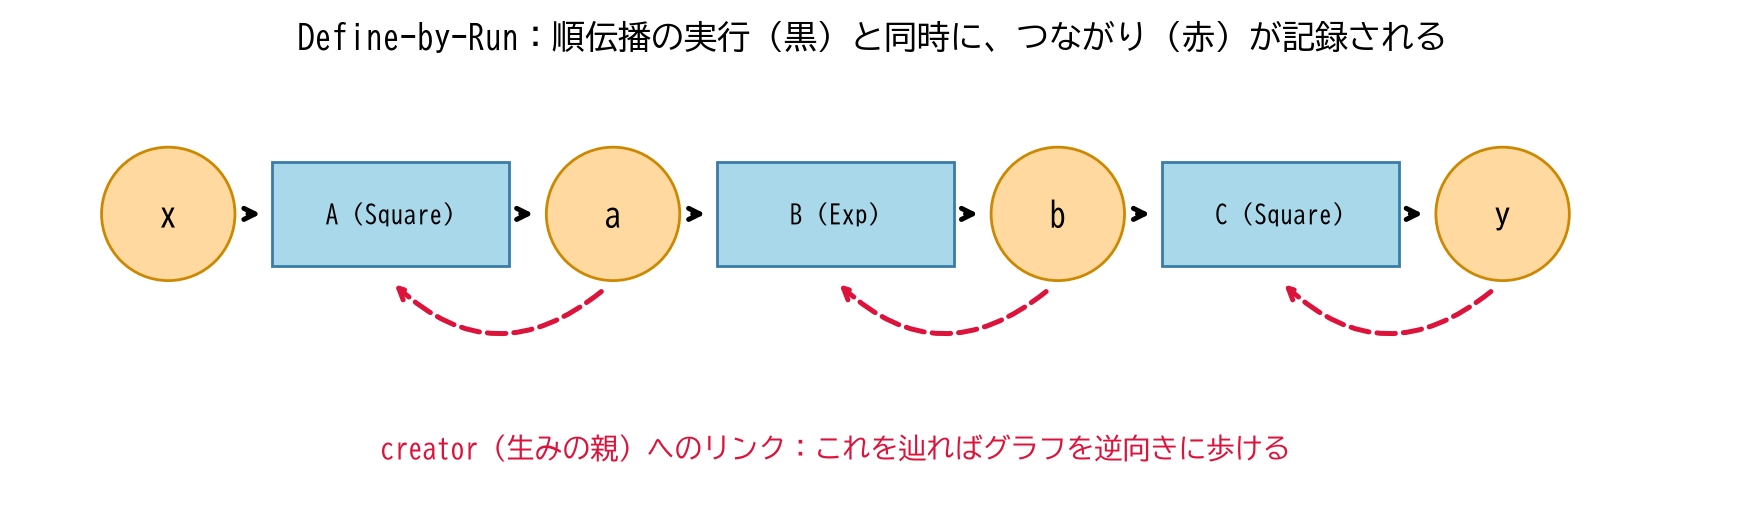

In [10]:
# 「つながり」を図にする：黒い矢印が順伝播の流れ、赤い破線が creator によるリンク
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.axis('off')
ax.set_aspect('equal')

y0 = 1.5
var_nodes = [("x", 0), ("a", 3), ("b", 6), ("y", 9)]
func_nodes = [("A (Square)", 1.5), ("B (Exp)", 4.5), ("C (Square)", 7.5)]

for lab, xi in var_nodes:
    ax.add_patch(plt.Circle((xi, y0), 0.45, color="#ffd9a0", ec="#cc8800", zorder=2))
    ax.text(xi, y0, lab, ha="center", va="center", fontsize=12, zorder=3)

for lab, xi in func_nodes:
    ax.add_patch(plt.Rectangle((xi - 0.8, y0 - 0.35), 1.6, 0.7, color="#a8d8ea", ec="#3a7ca5", zorder=2))
    ax.text(xi, y0, lab, ha="center", va="center", fontsize=9, zorder=3)

# 順伝播の矢印 (黒、左 → 右)
for x1, x2 in [(0.5, 0.66), (2.34, 2.5), (3.5, 3.66), (5.34, 5.5), (6.5, 6.66), (8.34, 8.5)]:
    ax.annotate("", xy=(x2, y0), xytext=(x1, y0),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.8))

# creator のリンク (赤い破線、変数 → 生みの親の関数)
for vx, fx in [(9, 7.5), (6, 4.5), (3, 1.5)]:
    ax.annotate("", xy=(fx, y0 - 0.45), xytext=(vx - 0.05, y0 - 0.5),
                arrowprops=dict(arrowstyle="->", color="crimson", lw=1.8,
                                linestyle="--", connectionstyle="arc3,rad=-0.45"))

ax.text(4.5, -0.15, "creator (生みの親) へのリンク：これを辿ればグラフを逆向きに歩ける",
        color="crimson", ha="center", fontsize=10)
ax.set_xlim(-1, 10.5)
ax.set_ylim(-0.45, 2.5)
ax.set_title("Define-by-Run：順伝播の実行 (黒) と同時に、つながり (赤) が記録される", fontsize=12)
plt.show()

## 7.2 つながりを使って逆伝播してみる

記録したつながりを使うと、ステップ 6 で手書きした逆伝播は、次の 3 手順の繰り返しに整理できる。

1. 変数の `creator` から関数を取得する
2. その関数の `input` (入力変数) を取得する
3. 関数の `backward` を呼び、入力変数の `grad` に微分をセットする

`y` から `x` に向かって、この手順を実際に 3 回繰り返してみる。

In [11]:
y.grad = np.array(1.0)

C = y.creator                # 1. 関数を取得
b = C.input                  # 2. 関数の入力を取得
b.grad = C.backward(y.grad)  # 3. 関数の backward を呼ぶ

B = b.creator                # 1. (以下、同じ手順の繰り返し)
a = B.input                  # 2.
a.grad = B.backward(b.grad)  # 3.

A = a.creator                # 1.
x = A.input                  # 2.
x.grad = A.backward(a.grad)  # 3.

print("x.grad =", x.grad)

x.grad = 3.297442541400256


## 7.3 `backward` メソッドの追加

まったく同じ 3 手順が 3 回繰り返されていた。この繰り返しを `Variable` 自身の `backward` メソッドとして実装すれば、自動化の完成である。「微分をセットしたら、1 つ前の変数の `backward` を呼ぶ」という再帰によって処理が連鎖し、`creator` が `None` の変数 (＝ユーザーが作ったグラフの端の変数) に達したところで自動的に止まる。

なお `Function`・`Square`・`Exp` は変更不要である (これらは実行時にグローバルの `Variable` を参照するので、再定義した新しいクラスが自動的に使われる)。

In [12]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None

    def set_creator(self, func):
        self.creator = func

    def backward(self):  # ★ 追加：7.2 の 3 手順を再帰で自動化
        f = self.creator                    # 1. 関数を取得
        if f is not None:                   # creator が None ならグラフの端 → 停止
            x = f.input                     # 2. 関数の入力を取得
            x.grad = f.backward(self.grad)  # 3. 関数の backward を呼ぶ
            x.backward()                    # 1 つ前の変数に対して繰り返す (再帰)


# 動作確認：順伝播のあと、y.backward() を 1 回呼ぶだけ
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)

y.grad = np.array(1.0)
y.backward()  # ★ これだけで x まで微分が伝わる
print("x.grad =", x.grad)

x.grad = 3.297442541400256


### 追加検証①：再帰の限界を見ておく

この `backward` は、自分の処理が終わらないうちに 1 つ前の変数の `backward` を呼ぶため、グラフが深いほど Python の呼び出しスタックが積み上がっていく。Python には再帰の深さ制限 (素の Python ではおよそ 1000、Jupyter 環境では 3000 に引き上げられていることが多い) があるので、深い計算グラフでは逆伝播が失敗するはずである。`Square` を 10000 個連結して試してみる。

In [13]:
import sys
print("Python の再帰の上限:", sys.getrecursionlimit())

x = Variable(np.array(0.5))
y = x
for _ in range(10000):  # Square を 10000 段連結した合成関数を作る (順伝播はループなので問題ない)
    y = Square()(y)

y.grad = np.array(1.0)
try:
    y.backward()
    print("逆伝播に成功")
except RecursionError:
    print("RecursionError：グラフが深すぎて、再帰による逆伝播は失敗した")

Python の再帰の上限: 3000
RecursionError：グラフが深すぎて、再帰による逆伝播は失敗した


> **ステップ 7 のまとめ**
> - 変数は生みの親の関数を `creator` として、関数は自分の入出力を `input`・`output` として覚える。これにより、順伝播を実行するだけで計算グラフのつながりが自動で記録される (Define-by-Run)。
> - つながりを出力側から辿る `backward` メソッドにより、`y.backward()` の 1 行で微分が自動計算されるようになった。
> - ただし再帰による実装は、深い計算グラフで再帰の上限に達して失敗する。次のステップでループに書き換える。

---
# ステップ 8：再帰からループへ

## 8.1 現時点の `Variable` クラス

いまの `backward` は「1 つ前の変数の `backward` を呼ぶ」という再帰で実装されている。動きはするが、追加検証①で見たとおり、深い計算グラフでは再帰の上限に達してしまう。

## 8.2 ループを使った実装

そこで、「処理すべき関数のリスト `funcs`」を自分で管理する方式に書き換える。

1. `funcs` から関数を 1 つ取り出す (`pop` はリスト末尾の要素を取り出す)
2. その関数の入力・出力の変数を取得し、`backward` を呼んで微分を 1 段伝える (出力は、ステップ 7 で `Function` に覚えさせた `self.output` から取れる)
3. 1 つ前の関数 (入力変数の `creator`) があれば `funcs` に追加する

これを `funcs` が空になるまで繰り返す。再帰版で Python のスタックに暗黙に積まれていた「あとで処理する仕事」を、明示的なリストに置き換えたと考えればよい。処理効率が良くなるのに加えて、この書き方には伏線としての意味もある。ステップ 15 で枝分かれのある複雑な計算グラフを扱う際、「次に処理すべき関数を賢く選ぶ」必要が出てくるが、リスト管理ならその拡張が素直にできる。

両者の違いを図にすると次のとおり。再帰はグラフの深さのぶんだけ呼び出しスタックを積み上げるのに対し、ループはスタックが常に 1 段のまま、リスト `funcs` の中身だけが入れ替わっていく。

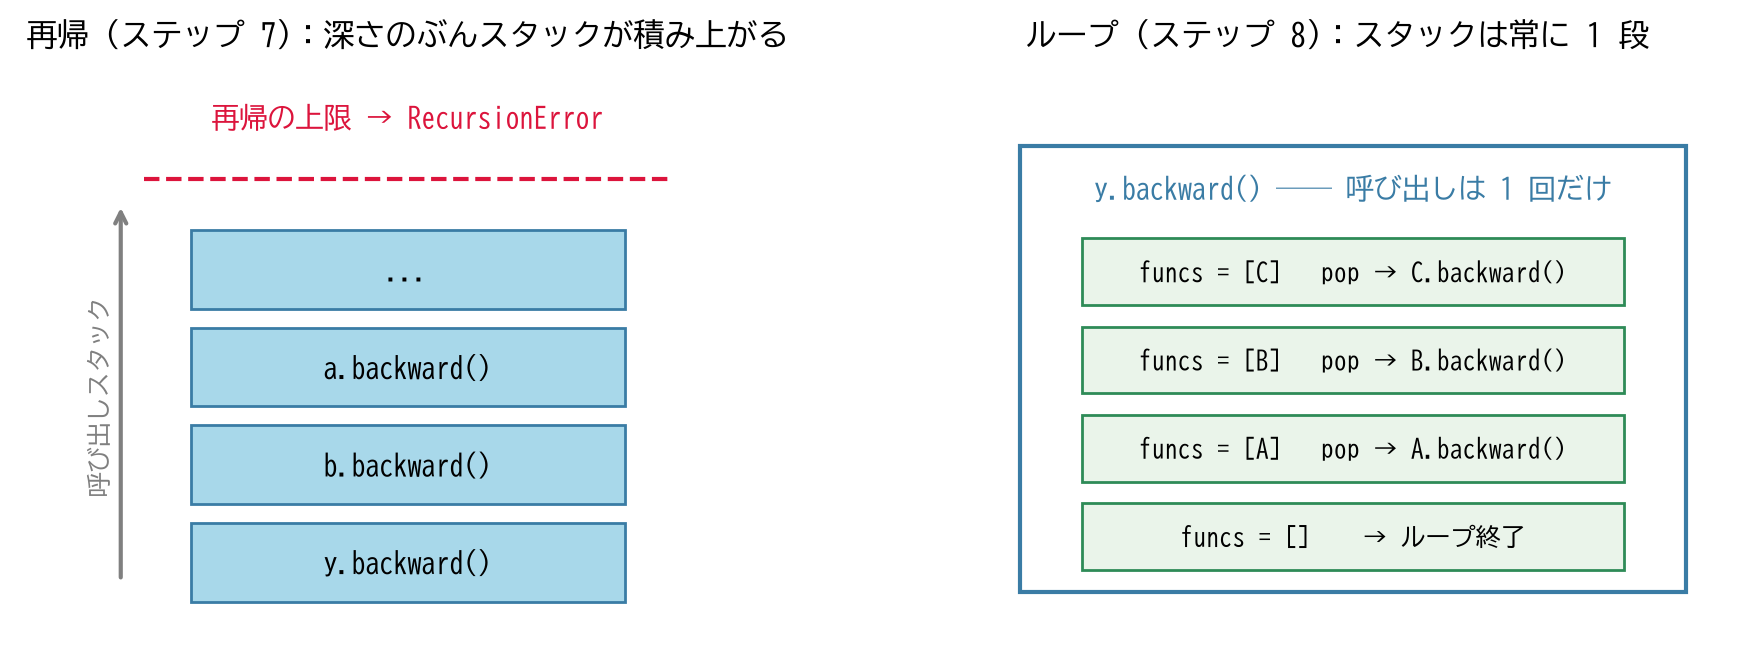

In [14]:
# 左：再帰は呼び出しスタックが深さぶん積み上がる / 右：ループはスタック 1 段のまま
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for ax in (ax1, ax2):
    ax.axis('off')
    ax.set_xlim(0, 10)
    ax.set_ylim(-0.5, 5.8)

# --- 左：再帰 (ステップ 7)
ax1.set_title("再帰 (ステップ 7)：深さのぶんスタックが積み上がる", fontsize=11)
for i, lab in enumerate(["y.backward()", "b.backward()", "a.backward()", "..."]):
    ax1.add_patch(plt.Rectangle((2.2, i * 1.05), 5.6, 0.85, color="#a8d8ea", ec="#3a7ca5"))
    ax1.text(5, i * 1.05 + 0.42, lab, ha="center", va="center", fontsize=10)
ax1.plot([1.6, 8.4], [4.55, 4.55], ls="--", color="crimson", lw=1.5)
ax1.text(5, 5.1, "再帰の上限 → RecursionError", color="crimson", ha="center", fontsize=10)
ax1.annotate("", xy=(1.3, 4.3), xytext=(1.3, 0.2),
             arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax1.text(0.85, 2.2, "呼び出しスタック", rotation=90, va="center", color="gray", fontsize=9)

# --- 右：ループ (ステップ 8)
ax2.set_title("ループ (ステップ 8)：スタックは常に 1 段", fontsize=11)
ax2.add_patch(plt.Rectangle((0.9, 0.1), 8.6, 4.8, fill=False, ec="#3a7ca5", lw=1.5))
ax2.text(5.2, 4.45, "y.backward() ── 呼び出しは 1 回だけ", ha="center", va="center",
         fontsize=10, color="#3a7ca5")
steps = ["funcs = [C]   pop → C.backward()",
         "funcs = [B]   pop → B.backward()",
         "funcs = [A]   pop → A.backward()",
         "funcs = []    → ループ終了"]
for i, lab in enumerate(steps):
    yline = 3.55 - i * 0.95
    ax2.add_patch(plt.Rectangle((1.7, yline - 0.36), 7.0, 0.72, color="#eaf4ea", ec="#2e8b57"))
    ax2.text(5.2, yline, lab, ha="center", va="center", fontsize=9)
plt.show()

In [15]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None

    def set_creator(self, func):
        self.creator = func

    def backward(self):  # ★ 変更：再帰をやめてループにする
        funcs = [self.creator]  # 処理すべき関数のリスト
        while funcs:
            f = funcs.pop()              # 1. 関数を取り出す
            x, y = f.input, f.output     # 2. 関数の入出力の変数を取得し、
            x.grad = f.backward(y.grad)  #    backward を呼んで微分を 1 段伝える

            if x.creator is not None:
                funcs.append(x.creator)  # 3. 1 つ前の関数をリストに追加

## 8.3 動作確認

いつもの合成関数で、再帰版と同じ結果になることを確かめる。

In [16]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)

y.grad = np.array(1.0)
y.backward()
print("x.grad =", x.grad)  # 再帰版と同じ 3.2974... になるはず

x.grad = 3.297442541400256


### 追加検証②：深いグラフでも動くことを確認

追加検証①で再帰版が失敗した「`Square` 10000 段」を、ループ版でもう一度試す。なお、0.5 を 10000 回も 2 乗すると値はアンダーフローして 0 になるため微分の値そのものは 0 になるが、ここでの主眼は逆伝播がエラーなく完走することである。

In [17]:
x = Variable(np.array(0.5))
y = x
for _ in range(10000):
    y = Square()(y)

y.grad = np.array(1.0)
y.backward()  # ループ実装なら呼び出しスタックを消費しない
print("10000 段の合成関数でも逆伝播が完走した：x.grad =", x.grad)

10000 段の合成関数でも逆伝播が完走した：x.grad = 0.0


再帰版とループ版の比較を整理しておく。

| | 再帰 (ステップ 7) | ループ (ステップ 8) |
|---|---|---|
| 実装 | シンプル | リストの管理が少し増える |
| スタック消費 | グラフの深さに比例 | 一定 |
| 深い計算グラフ | RecursionError (追加検証①) | 問題なく完走 (追加検証②) |
| 複雑なグラフへの拡張 | 難しい | しやすい (ステップ 15 で活きる) |

> **ステップ 8 のまとめ**
> - `backward` を再帰からループに書き換えた。結果は同じだが、深い計算グラフでも動作し、処理効率も良い。
> - 「処理すべき関数」を明示的なリストで管理するこの方式は、ステップ 15 で複雑な計算グラフに対応するときの土台になる。

---
# ステップ 9：関数をより便利に

DeZero は、逆伝播を自動で行える段階まで来た。このステップでは、DeZero を「使う人」の目線で 3 つの改善を行う。

| 節 | 改善 | ビフォー → アフター |
|---|---|---|
| 9.1 | Python の関数として使えるように | `y = Square()(x)` → `y = square(x)` |
| 9.2 | `grad` の自動初期化 | `y.grad = np.array(1.0)` を書かなくてよい |
| 9.3 | `ndarray` だけを扱う | `Variable(1.0)` は `TypeError`。出力は常に `ndarray` |

## 9.1 Python の関数として利用する

いまの DeZero の関数を使うには、`f = Square()` とインスタンスを作ってから `f(x)` と呼ぶという 2 段階が必要で回りくどい。そこで、「インスタンスを作って呼ぶ」を 1 行にまとめた Python 関数を用意する。

In [18]:
def square(x):
    return Square()(x)  # 「Square クラスのインスタンスを作って呼ぶ」を 1 行に


def exp(x):
    return Exp()(x)


# 普通の数式のように、関数を連続して適用できるようになった
x = Variable(np.array(0.5))
y = square(exp(square(x)))  # y = (exp(x^2))^2
y.grad = np.array(1.0)      # ← この行はまだ手で書く必要がある (次の 9.2 で解消する)
y.backward()
print("x.grad =", x.grad)

x.grad = 3.297442541400256


`y = square(exp(square(x)))` と、NumPy を使う普通のコードと同じ感覚で書けるようになった。

## 9.2 `backward` メソッドの簡略化

毎回 `y.grad = np.array(1.0)` と書く手間も省きたい。逆伝播の出発点は常に $\dfrac{dy}{dy} = 1$ なのだから、`backward()` が呼ばれたときに `grad` が未設定 (`None`) なら、自動で 1 を用意すればよい。実装には `np.ones_like(self.data)` を使う。これは `self.data` と同じ形状・同じデータ型で、要素がすべて 1 の `ndarray` を作る関数である。

## 9.3 `ndarray` だけを扱う

DeZero の `Variable` は、NumPy の `ndarray` 専用の箱のつもりで設計している。ところが今は `Variable(1.0)` のように `float` や `int` を入れても一見動いてしまい、後々の思わぬバグの温床になる。そこで 2 つの手当てをする。

**(1) 入力の型チェック**：`Variable.__init__` で、`ndarray` と `None` 以外が来たら `TypeError` を出してその場で知らせる (`None` は「まだ中身のない箱」として許可しておく)。

**(2) 計算結果の型の保証**：実は NumPy には少し厄介な仕様がある。0 次元の `ndarray` を計算すると、結果が `ndarray` ではなく `np.float64` などのスカラ型になるのだ。まずはその挙動を確認する。

In [19]:
x = np.array(1.0)  # 0 次元の ndarray
y = x ** 2
print("x の型:", type(x))  # <class 'numpy.ndarray'>
print("y の型:", type(y))  # <class 'numpy.float64'> ← ndarray でなくなってしまう！

# np.isscalar で「スカラ型かどうか」を判定できる
print(np.isscalar(np.float64(1.0)))  # True
print(np.isscalar(2.0))              # True
print(np.isscalar(np.array(1.0)))    # False (0 次元でも ndarray は False)

x の型: <class 'numpy.ndarray'>
y の型: <class 'numpy.float64'>
True
True
False


つまり `forward` の計算結果は、入力が 0 次元のときだけスカラ型になり得る。それをそのまま箱に詰めると、今度は (1) の型チェックに引っかかってしまう。そこで、スカラ型なら `ndarray` に変換して返すヘルパー関数 `as_array` を用意し、`Function.__call__` では出力を必ず `as_array` に通してから `Variable` に詰めることにする。この処理の流れを図にすると次のようになる。

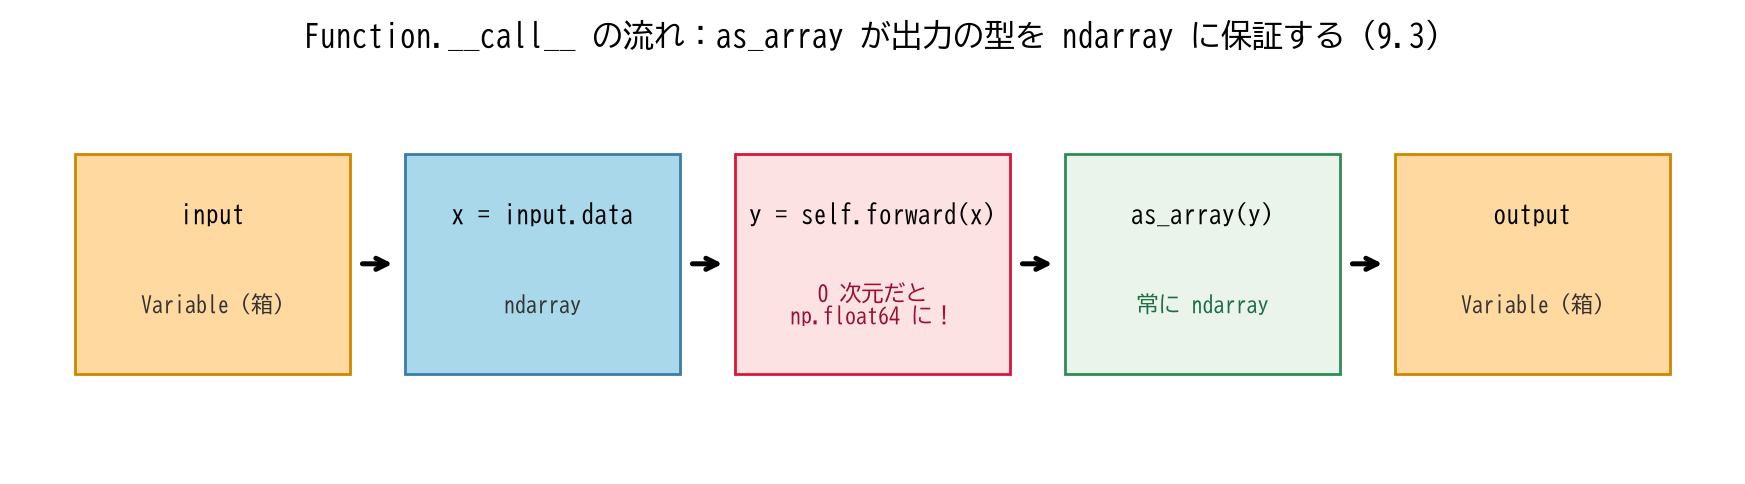

In [20]:
# Function.__call__ の処理の流れ：as_array が出力の型を ndarray に保証する
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.axis('off')

stages = [
    ("input", "Variable (箱)", "#ffd9a0", "#cc8800", "#333333"),
    ("x = input.data", "ndarray", "#a8d8ea", "#3a7ca5", "#333333"),
    ("y = self.forward(x)", "0 次元だと\nnp.float64 に！", "#fde2e4", "crimson", "#9b1030"),
    ("as_array(y)", "常に ndarray", "#eaf4ea", "#2e8b57", "#1d6f42"),
    ("output", "Variable (箱)", "#ffd9a0", "#cc8800", "#333333"),
]
for i, (lab, sub, fc, ec, sc) in enumerate(stages):
    xc = i * 2.4
    ax.add_patch(plt.Rectangle((xc - 1.0, -0.55), 2.0, 1.1, color=fc, ec=ec, zorder=2))
    ax.text(xc, 0.25, lab, ha="center", va="center", fontsize=9, zorder=3)
    ax.text(xc, -0.2, sub, ha="center", va="center", fontsize=8, color=sc, zorder=3)
    if i > 0:
        ax.annotate("", xy=(xc - 1.05, 0), xytext=(xc - 1.35, 0),
                    arrowprops=dict(arrowstyle="->", color="black", lw=1.8))

ax.set_xlim(-1.4, 11.0)
ax.set_ylim(-1.0, 1.0)
ax.set_title("Function.__call__ の流れ：as_array が出力の型を ndarray に保証する (9.3)", fontsize=11)
plt.show()

以上 3 つの改善 (9.1〜9.3) をすべて反映した DeZero が以下である。

In [21]:
class Variable:
    def __init__(self, data):
        if data is not None:  # ★ 9.3 (1)：ndarray と None 以外はエラーにする
            if not isinstance(data, np.ndarray):
                raise TypeError('{} is not supported'.format(type(data)))

        self.data = data
        self.grad = None
        self.creator = None

    def set_creator(self, func):
        self.creator = func

    def backward(self):
        if self.grad is None:  # ★ 9.2：grad が未設定なら dy/dy = 1 を自動でセット
            self.grad = np.ones_like(self.data)

        funcs = [self.creator]
        while funcs:
            f = funcs.pop()
            x, y = f.input, f.output
            x.grad = f.backward(y.grad)

            if x.creator is not None:
                funcs.append(x.creator)


def as_array(x):  # ★ 9.3 (2)：スカラ型なら ndarray に変換するヘルパー関数
    if np.isscalar(x):
        return np.array(x)
    return x


class Function:
    def __call__(self, input):
        x = input.data
        y = self.forward(x)
        output = Variable(as_array(y))  # ★ 9.3 (2)：出力を必ず ndarray にして箱に詰める
        output.set_creator(self)
        self.input = input
        self.output = output
        return output

    def forward(self, x):
        raise NotImplementedError()

    def backward(self, gy):
        raise NotImplementedError()


class Square(Function):
    def forward(self, x):
        y = x ** 2
        return y

    def backward(self, gy):
        x = self.input.data
        gx = 2 * x * gy
        return gx


class Exp(Function):
    def forward(self, x):
        y = np.exp(x)
        return y

    def backward(self, gy):
        x = self.input.data
        gx = np.exp(x) * gy
        return gx

これで、このステージの冒頭に掲げた目標のコードがそのまま動くようになった (9.1 の `square`・`exp` は、実行時にグローバルの `Square`・`Exp` を参照するため再定義不要)。

In [22]:
x = Variable(np.array(0.5))
y = square(exp(square(x)))
y.backward()  # y.grad の手動セットが不要になった
print("x.grad =", x.grad)

x.grad = 3.297442541400256


型チェックの動作も確認しておく。

In [23]:
x = Variable(np.array(1.0))  # OK：ndarray
x = Variable(None)           # OK：None は許可 (空の箱)
try:
    x = Variable(1.0)        # NG：float はエラーになる
except TypeError as e:
    print("TypeError:", e)

TypeError: <class 'float'> is not supported


> **ステップ 9 のまとめ**
> - `square(x)`・`exp(x)` という Python 関数を用意し、数式のように自然に書けるようにした。
> - `backward()` が出発点の微分 ($dy/dy = 1$) を自動で用意するようにした。
> - `Variable` は `ndarray` (と `None`) だけを受け付け、`Function` の出力も `as_array` で必ず `ndarray` に揃えた。これは「0 次元 `ndarray` の計算結果はスカラ型になる」という NumPy の仕様への対策である。

---
# ステップ 10：テストを行う

DeZero のようなフレームワークは、小さな部品を積み上げて作っていく。土台の部品にバグがあると、その上に作るものすべてが疑わしくなる。そこでソフトウェア開発の定石にならい、テストを書いて実装の正しさをいつでも確認できるようにする。

## 10.1 `unittest` によるテスト

Python 標準ライブラリの `unittest` を使う。作法は次のとおり。

- `unittest.TestCase` を継承したクラスを作る
- 名前が `test` で始まるメソッドを書く。その 1 つ 1 つがテストケースになる
- 結果の検証には `self.assertEqual` (等しいか)・`self.assertTrue` (真か) などの専用メソッドを使う

まずは `square` 関数の順伝播のテスト。入力 `2.0` に対して出力が `4.0` になることを確認する。

## 10.2 逆伝播のテスト

同様に逆伝播もテストする。入力 `3.0` のとき、`y.backward()` 後の `x.grad` が解析解 $2x = 6.0$ と一致するかを見る。

## 10.3 勾配確認による自動テスト

10.2 には「期待値 (`6.0`) を人間が手計算して用意する」という手間がある。これを省く定石が勾配確認 (gradient checking) である。ステップ 4 で「数値微分は、バックプロパゲーションの検算に使える」と述べたことを、ここで実行に移す。

- ランダムな入力を作る
- バックプロパゲーションによる微分と、数値微分の結果を両方求める
- `np.allclose(a, b)` で 2 つが「ほぼ等しい」ことを確認する (数値微分には誤差があるため、完全一致ではなく近さで判定する)

テストコードを書く前に、勾配確認の流れを実際の数値で見ておく。同じ入力 `x` から、互いに独立な 2 つのルートで微分を求め、`np.allclose` で突き合わせる。

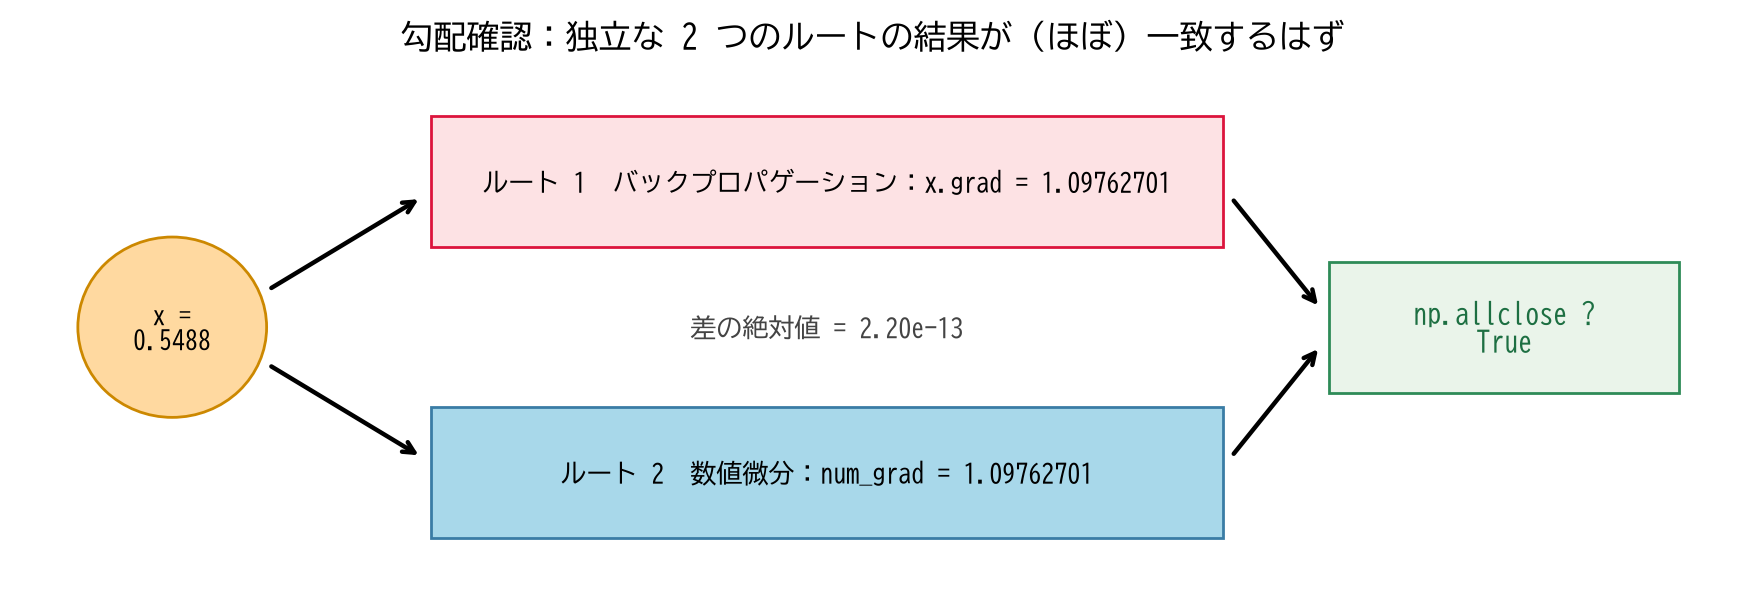

In [24]:
# 勾配確認：同じ入力から 2 つの独立したルートで微分を求めて突き合わせる
x0 = Variable(np.random.rand(1))        # ランダムな入力
y0 = square(x0)
y0.backward()
bp = x0.grad.item()                     # ルート 1：バックプロパゲーション
ng = numerical_diff(square, x0).item()  # ルート 2：数値微分

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.axis('off')

ax.add_patch(plt.Circle((1.0, 1.5), 0.62, color="#ffd9a0", ec="#cc8800", zorder=2))
ax.text(1.0, 1.5, f"x =\n{x0.data.item():.4f}", ha="center", va="center", fontsize=9, zorder=3)

ax.add_patch(plt.Rectangle((2.7, 2.05), 5.2, 0.9, color="#fde2e4", ec="crimson", zorder=2))
ax.text(5.3, 2.5, f"ルート 1  バックプロパゲーション：x.grad = {bp:.8f}", ha="center", va="center",
        fontsize=9.5, zorder=3)
ax.add_patch(plt.Rectangle((2.7, 0.05), 5.2, 0.9, color="#a8d8ea", ec="#3a7ca5", zorder=2))
ax.text(5.3, 0.5, f"ルート 2  数値微分：num_grad = {ng:.8f}", ha="center", va="center",
        fontsize=9.5, zorder=3)

ax.add_patch(plt.Rectangle((8.6, 1.05), 2.3, 0.9, color="#eaf4ea", ec="#2e8b57", zorder=2))
ax.text(9.75, 1.5, f"np.allclose ?\n{np.allclose(x0.grad, ng)}", ha="center", va="center",
        fontsize=10, color="#1d6f42", zorder=3)

for y_from, y_to in [(1.75, 2.4), (1.25, 0.6)]:
    ax.annotate("", xy=(2.65, y_to), xytext=(1.62, y_from),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.6))
for y_from, y_to in [(2.4, 1.62), (0.6, 1.38)]:
    ax.annotate("", xy=(8.55, y_to), xytext=(7.95, y_from),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.6))

ax.text(5.3, 1.5, f"差の絶対値 = {abs(bp - ng):.2e}", ha="center", va="center",
        fontsize=9.5, color="#444444")
ax.set_xlim(0, 11.2)
ax.set_ylim(-0.3, 3.3)
ax.set_title("勾配確認：独立な 2 つのルートの結果が (ほぼ) 一致するはず", fontsize=12)
plt.show()

In [25]:
import unittest


class SquareTest(unittest.TestCase):
    def test_forward(self):
        x = Variable(np.array(2.0))
        y = square(x)
        expected = np.array(4.0)
        self.assertEqual(y.data, expected)  # 順伝播：2^2 = 4

    def test_backward(self):
        x = Variable(np.array(3.0))
        y = square(x)
        y.backward()
        expected = np.array(6.0)
        self.assertEqual(x.grad, expected)  # 逆伝播：解析解 2x = 6 と比較

    def test_gradient_check(self):
        x = Variable(np.random.rand(1))       # ランダムな入力を 1 つ作る
        y = square(x)
        y.backward()
        num_grad = numerical_diff(square, x)  # ステップ 4 の数値微分で検算
        flg = np.allclose(x.grad, num_grad)   # 「ほぼ等しい」なら True
        self.assertTrue(flg)

スクリプトファイルなら `python -m unittest ファイル名` のように実行するが、ノートブック上では次のようにしてテストを実行できる。

In [26]:
# ノートブック上でテストを実行する
suite = unittest.TestLoader().loadTestsFromTestCase(SquareTest)
result = unittest.TextTestRunner(verbosity=2).run(suite)

test_backward (__main__.SquareTest.test_backward) ... ok
test_forward (__main__.SquareTest.test_forward) ... ok
test_gradient_check (__main__.SquareTest.test_gradient_check) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.004s

OK


3 つのテストがすべて `ok` になった (unittest のレポートは標準エラー出力に出るため、環境によっては赤い背景で表示されるが、エラーではない)。

実際の開発では、テストファイルを `tests` ディレクトリにまとめておき、`python -m unittest discover tests` で一括実行する。DeZero 本家のリポジトリでも [tests ディレクトリ](https://github.com/oreilly-japan/deep-learning-from-scratch-3/tree/master/tests) にテスト群が置かれ、コードを更新するたびに自動でテストが走る継続的インテグレーション (CI) が組まれている。テストを積み重ねることが、フレームワークを安心して拡張していくための土台になる。

> **ステップ 10 のまとめ**
> - `unittest.TestCase` を継承し、`test` で始まるメソッドを書けばテストになる。
> - 順伝播・逆伝播の期待値テストに加えて、数値微分と突き合わせる勾配確認を使えば、期待値を手計算しなくても逆伝播の正しさを機械的に検証できる。
> - ステップ 4 の数値微分が「検算役」としてここで活きた。

---

# 今回のまとめ

第 1 ステージの後半 (ステップ 6〜10) で、前回の理論どおりにバックプロパゲーションを実装し、自動微分が完成した。

1. ステップ 6 手作業によるバックプロパゲーション：`Variable` に `grad` を、`Function` に `backward` と入力の記憶を追加。出力側から `backward` を手で呼べば微分が求まることを確認した。
2. ステップ 7 自動化：変数が生みの親 (`creator`) を覚えることで、計算グラフのつながりが実行時に記録される (Define-by-Run)。`y.backward()` の 1 行で逆伝播が動くようになった。
3. ステップ 8 再帰からループへ：深い計算グラフでも動く実装にした。複雑なグラフへの拡張 (ステップ 15) に向けた布石でもある。
4. ステップ 9 使い勝手の改善：`square(x)` と書ける関数化、出発点の `grad` の自動初期化、`ndarray` だけを扱うための型チェックと `as_array`。
5. ステップ 10 テスト：`unittest` による順伝播・逆伝播のテストに加え、数値微分との勾配確認で「期待値の手計算」も不要にした。

これで第 1 ステージは完結し、「`y.backward()` を実行するだけで微分が求まる」という当初の目標が達成された。次回からの第 2 ステージ (ステップ 11〜) では、可変長の入出力への対応、枝分かれのある計算グラフ、`a * b + c` と書くための演算子オーバーロードなど、DeZero をより自然なコードで使えるように拡張していく。